<a href="https://colab.research.google.com/github/wingated/cs473/blob/main/mini_labs/week_3_correlation.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# BYU CS 473 — Correlation, Causation, and Simpson’s Paradox

In this assignment, you will learn to distinguish between correlation, causation, and independence, and explore the concept of **Simpson’s Paradox**.

---

## Learning Goals
- Understand the difference between correlation and causation  
- Understand why correlation does not imply independence  
- Understand why correlation ≠ causation  
- Recognize and explain Simpson’s Paradox  

## 1. Correlation

Correlation measures the strength and direction of a linear relationship between two variables.  

- Positive correlation → as one variable increases, the other tends to increase.  
- Negative correlation → as one increases, the other tends to decrease.  
- Zero correlation → no linear relationship.  

We use **Pearson’s correlation coefficient**:  
$r = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}$


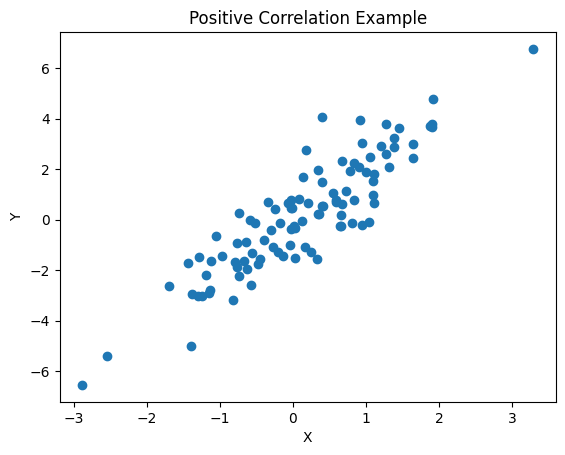

np.float64(0.8924441843003862)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Example: positively correlated variables
x = np.random.normal(0, 1, 100)
y = 2 * x + np.random.normal(0, 1, 100)

plt.scatter(x, y)
plt.title("Positive Correlation Example")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

np.corrcoef(x, y)[0, 1]


### Exercise 1
Generate two negatively correlated variables and compute their correlation coefficient.  
Plot them with a scatterplot.


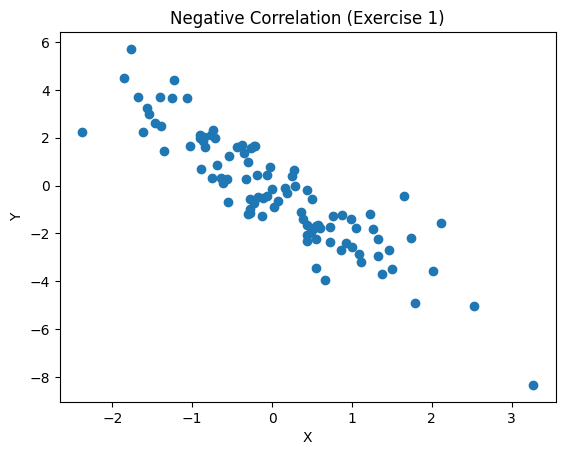

np.float64(-0.8940620882860417)

In [4]:
# Your code here
x = np.random.normal(0, 1, 100)
y = -2 * x + np.random.normal(0, 1, 100)

plt.scatter(x, y)
plt.title("Negative Correlation (Exercise 1)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

np.corrcoef(x, y)[0, 1]

## 2. Correlation ≠ Independence

Two variables can be **uncorrelated** but still **dependent**.  

Example: Let  
$X \sim N(0,1), \quad Y = X^2$

- Correlation between X and Y = 0 (no linear relationship).  
- But Y is completely determined by X (they are dependent).


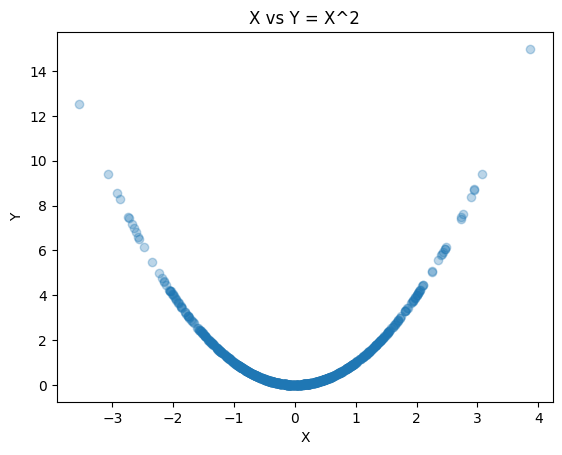

np.float64(0.036024362862585556)

In [5]:
x = np.random.normal(0, 1, 1000)
y = x**2

plt.scatter(x, y, alpha=0.3)
plt.title("X vs Y = X^2")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

np.corrcoef(x, y)[0, 1]


### Exercise 2
Try another example: define `Y = cos(X)` for `X` sampled uniformly from [-π, π].  
- Plot `X` vs `Y`.  
- Compute the correlation coefficient.  
- Are X and Y independent? Why or why not?


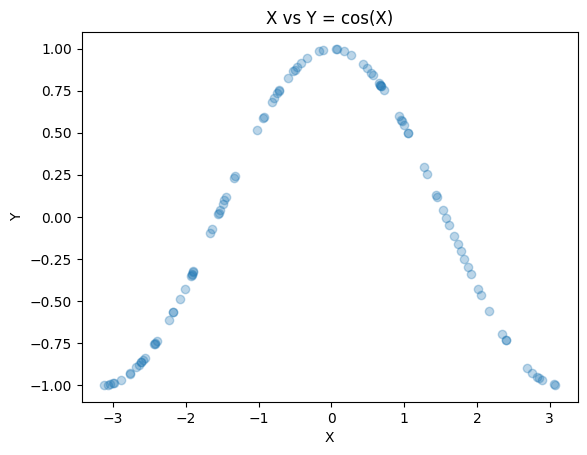

np.float64(0.036024362862585556)

In [10]:
# Your code here
X = np.random.uniform(low=-np.pi, high=np.pi, size=100)
Y = np.cos(X)

plt.scatter(X, Y, alpha=0.3)
plt.title("X vs Y = cos(X)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

np.corrcoef(x, y)[0, 1]


# **Response (Exercise 2, Part 3)**

Yes; `X` and `Y` are dependent because the variable Y is determined by the function `cos(X)`.  That is, knowing the value of `X` exactly determines the value of `Y`, which is the strongest form of dependence possible.  This is true even though `X` and `Y` are uncorrelated (the expected value of both variables is cleverly chosen to be zero).

## 3. Simpson’s Paradox

Simpson’s Paradox occurs when a trend appears in different groups of data but reverses when the groups are combined.

Example: University admissions data:  

- Group A (Men vs Women): higher female admit rate  
- Group B (Men vs Women): higher female admit rate  
- Combined: women appear to have lower admit rate  


In [13]:
import pandas as pd

# Simulated data
data = pd.DataFrame({
    "Department": ["A"]*100 + ["B"]*100,
    "Gender": ["M"]*80 + ["F"]*20 + ["M"]*20 + ["F"]*80,
    "Admitted": [1]*60 + [0]*20 + [1]*15 + [0]*5 + [1]*10 + [0]*10 + [1]*40 + [0]*40
})

# Grouped admit rates
print(data.groupby(["Department", "Gender"])["Admitted"].mean())
print("\nOverall rates:")
print(data.groupby("Gender")["Admitted"].mean())


Department  Gender
A           F         0.75
            M         0.75
B           F         0.50
            M         0.50
Name: Admitted, dtype: float64

Overall rates:
Gender
F    0.55
M    0.70
Name: Admitted, dtype: float64


### Exercise 3
1. Interpret the paradox in the example above.  
2. Why does the paradox occur?  
3. Provide one real-world situation where Simpson’s Paradox could mislead decision-making.


1. Even though admissions levels appear equal for both men and women across each department (and they are), the overall admission rate shows that men are more likely to be admitted than women overall.  The paradox is that every department has an equal admissions rate for both men and women, while the collection of all departments has a higher acceptance rate for men than it does for women.

2. This paradox occurs because even though each department has the same admission rate for men and women, the admission rate varies between the two departments.  Because women disproportionately apply to the department with a lower admissions rate (and men disproportionately apply to the department with a higher admissions rate), the overall admissions rate for women is lower than men.  That is, we should weight the admissions rate of each department by the overall proportion of men (or women) that apply to that department.  In this case, 80% of women apply to department B and 80% of men apply to department A, so the overall admissions rates are given by:

`Men:  (0.80)(0.75) + (0.20)(0.50) = 70%`
`Women:  (0.20)(0.75) + (0.80)(0.50) = 55%`.

3. One of the most significant illustrations of Simpson's Paradox in the real world is in medical trials.  Because the sample sizes are rarely equivalent across separate experiments, we find similar paradoxes as the one found in this Exercise (with college admissions), where one treatment may appear better than another in all subgroups, but worse overall in the aggregate group.  This highlights just how essential it is to analyze the results critically both in subgroups and across the whole (especially in accounting for tests across different-sized cohorts) before drawing any conclusions.